<img src="logos/Logo_de_la_Facultad_Experimental_de_Ciencia_y_Tecnología.svg.png"
     width="250"
     style="display: block; margin-left: auto; margin-right: auto;">

# Exploratory Data Analysis: Premier League

## Purpose

This notebook presents a teaching example of **exploratory data analysis (EDA)**. Its goal is to understand the dataset's structure, quality, and patterns before building a model to predict the result of a football match.

EDA is not intended to prove causality or make final modeling decisions. It aims to:

- detect data quality issues;
- describe distributions and relationships;
- formulate hypotheses;
- acknowledge uncertainty and limitations;
- propose decisions that must later be validated.

**Unit of observation:** Un partido de futbol de la liga inglesa  
**Target variable:** `FTR` Full Time Result (`H`=Home Win, `D`=Draw, `A`=Away Win)  
**Downstream problem type:** Clasificacion Multiclase.


## Guiding questions

1. Which variables and data types does the dataset contain?
2. Are there duplicates, missing values, or suspicious values?
3. How is the target variable distributed?
4. How is the result associated with home/away, season, half-time result, and team strength?
5. Are there relevant interactions between variables?
6. What useful information can be extracted from the bookmaker odds?
7. Which preprocessing hypotheses should be validated during modeling?

> The observed associations describe this sample. By themselves, they do not imply causal relationships.


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42

# Allow execution from either the project root or the notebooks/ directory.
PROJECT_ROOT = Path.cwd()
print(PROJECT_ROOT)
if not (PROJECT_ROOT  / "data" / "processed" / "premier_league_2021_2026.csv" ).exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "premier_league_2021_2026.csv"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), f"Dataset not found at {DATA_PATH}"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", "{:.3f}".format)
plt.style.use("seaborn-v0_8-whitegrid")


c:\Users\user\Documents\Github\premier_league_football_predictor\notebooks


In [4]:
premier_df = pd.read_csv(DATA_PATH)

print(f"Dimensions: {premier_df.shape[0]} rows × {premier_df.shape[1]} columns")
premier_df.head()


Dimensions: 1900 rows × 157 columns


,Season,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,BVH,BVD,BVA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,BVCH,BVCD,BVCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFH,BFD,BFA,1XBH,1XBD,1XBA,BFEH,BFED,BFEA,BFE>2.5,BFE<2.5,BFEAHH,BFEAHA,BFCH,BFCD,BFCA,1XBCH,1XBCD,1XBCA,BFECH,BFECD,BFECA,BFEC>2.5,BFEC<2.5,BFECAHH,BFECAHA,BFDH,BFDD,BFDA,BMGMH,BMGMD,BMGMA,CLH,CLD,CLA,LBH,LBD,LBA,BFDCH,BFDCD,BFDCA,BMGMCH,BMGMCD,BMGMCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA
0,2021-2022,E0,13/08/2021,20:00,Brentford,Arsenal,2,0,H,1,0,H,M Oliver,8,22,3,4,12,8,2,5,0,0,0,0,4.000,3.400,1.950,4.000,3.500,1.950,3.800,3.400,2.050,4.050,3.460,2.050,4.000,3.400,1.900,4.100,3.400,2.000,4.620,3.720,2.100,4.020,3.430,2.020,2.100,1.720,2.220,1.730,2.260,1.830,2.160,1.730,0.500,1.860,2.070,1.880,2.060,2.050,2.080,1.870,2.030,3.800,3.250,2.050,3.800,3.300,2.050,3.800,3.250,2.100,3.940,3.330,2.130,3.900,3.000,2.050,3.900,3.250,2.100,4.200,3.500,2.180,3.890,3.280,2.100,2.370,1.570,2.440,1.620,2.470,1.750,2.330,1.620,0.500,1.750,2.050,1.810,2.130,2.050,2.170,1.800,2.090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-2022,E0,14/08/2021,12:30,Man United,Leeds,5,1,H,1,0,H,P Tierney,16,10,8,3,11,9,5,4,1,2,0,0,1.530,4.500,5.750,1.530,4.500,5.750,1.550,4.400,5.750,1.560,4.570,5.960,1.520,4.330,5.800,1.550,4.400,6.000,1.590,4.650,6.350,1.550,4.480,5.870,1.610,2.300,1.670,2.320,1.710,2.380,1.650,2.290,-1.000,1.950,1.980,1.960,1.960,2.000,2.010,1.930,1.960,1.610,4.200,5.250,1.620,4.100,5.250,1.650,4.200,4.900,1.670,4.200,5.400,1.570,4.200,5.500,1.650,4.100,5.250,1.710,4.330,5.800,1.640,4.190,5.220,1.660,2.200,1.700,2.270,1.750,2.370,1.670,2.250,-1.000,2.050,1.750,2.170,1.770,2.190,1.930,2.100,1.790,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-2022,E0,14/08/2021,15:00,Burnley,Brighton,1,2,A,1,0,H,D Coote,14,14,3,8,10,7,7,6,2,1,0,0,3.100,3.100,2.450,3.200,3.100,2.400,3.150,3.050,2.450,3.300,3.120,2.510,3.200,3.000,2.450,3.130,3.100,2.450,3.330,3.200,2.600,3.190,3.090,2.490,2.500,1.530,2.560,1.560,2.560,1.630,2.460,1.570,0.250,1.800,2.140,1.830,2.120,1.830,2.170,1.790,2.120,3.100,3.100,2.450,3.250,3.100,2.400,3.100,3.050,2.450,3.270,3.140,2.510,3.100,3.000,2.450,3.130,3.130,2.500,3.350,3.200,2.560,3.190,3.100,2.480,2.300,1.610,2.330,1.670,2.420,1.710,2.340,1.620,0.250,1.790,2.150,1.810,2.140,1.820,2.190,1.790,2.120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-2022,E0,14/08/2021,15:00,Chelsea,Crystal Palace,3,0,H,2,0,H,J Moss,13,4,6,1,15,11,5,2,0,0,0,0,1.250,5.750,13.000,1.280,5.750,10.500,1.250,6.000,13.000,1.260,6.240,12.740,1.250,5.500,13.000,1.250,5.750,13.000,1.300,6.300,15.000,1.260,5.920,12.800,1.800,2.000,1.800,2.090,1.840,2.120,1.790,2.060,-1.500,1.840,2.090,1.790,2.120,1.930,2.120,1.830,2.070,1.300,5.250,11.000,1.330,5.000,10.000,1.300,5.250,11.000,1.340,5.400,11.000,1.300,5.250,10.000,1.330,5.000,11.000,1.360,5.500,11.500,1.330,5.170,10.580,1.900,1.900,1.930,1.980,1.960,2.070,1.900,1.940,-1.500,2.050,1.750,2.120,1.810,2.160,1.930,2.060,1.820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

# 1. Data understanding and quality

We begin by examining the dataset's structure. The data types stored by pandas do not always match each variable's analytical role:

- `Season` es un identificador de la temporada de donde son los datos se guardan como strings.
- `Div` nos dice la division de la liga y tambien se guarda como strings
- `Date` and `Time` Son variables de tipo string para representar la fecha y hora.
- `HomeTeam` y `AwayTeam` Contienen textos que representan a los equipos.
- `FTR` and `HTR` Son los resultados de tanto del partido completo y de medio tiempo respectivamente, este es categorico entre (H=Home,A=Away,D=Draw)
- Las columnas de odds (`B365H`, `AvgH`, ...) son numéricas y codifican la probabilidad implícita del mercado para cada resultado.


In [5]:
premier_df.info( verbose=True, show_counts=True )

<class 'pandas.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 157 columns):
 #    Column     Non-Null Count  Dtype  
---   ------     --------------  -----  
 0    Season     1900 non-null   str    
 1    Div        1900 non-null   str    
 2    Date       1900 non-null   str    
 3    Time       1900 non-null   str    
 4    HomeTeam   1900 non-null   str    
 5    AwayTeam   1900 non-null   str    
 6    FTHG       1900 non-null   int64  
 7    FTAG       1900 non-null   int64  
 8    FTR        1900 non-null   str    
 9    HTHG       1900 non-null   int64  
 10   HTAG       1900 non-null   int64  
 11   HTR        1900 non-null   str    
 12   Referee    1900 non-null   str    
 13   HS         1900 non-null   int64  
 14   AS         1900 non-null   int64  
 15   HST        1900 non-null   int64  
 16   AST        1900 non-null   int64  
 17   HF         1900 non-null   int64  
 18   AF         1900 non-null   int64  
 19   HC         1900 non-null   int64  
 

In [6]:
quality_summary = pd.DataFrame({
    "dtype": premier_df.dtypes.astype(str),
    "missing_n": premier_df.isna().sum(),
    "missing_pct": premier_df.isna().mean().mul(100),
    "unique_n": premier_df.nunique(dropna=True),
})
quality_summary.sort_values("missing_pct", ascending=False )


,dtype,missing_n,missing_pct,unique_n
CLCH,float64,1640,86.316,73
CLCA,float64,1640,86.316,68
CLCD,float64,1640,86.316,30
LBCH,float64,1619,85.211,74
LBCD,float64,1619,85.211,30
LBCA,float64,1619,85.211,71
CLD,float64,1618,85.158,29
CLH,float64,1618,85.158,75
CLA,float64,1618,85.158,74
LBH,float64,1614,84.947,76


In [7]:
checks = pd.Series({
    "duplicated_rows": premier_df.duplicated().sum(),
    "negative_goals_home": premier_df["FTHG"].lt(0).sum(),
    "negative_goals_away": premier_df["FTAG"].lt(0).sum(),
    "negative_goals_home_half_time": premier_df["HTHG"].lt(0).sum(),
    "negative_goals_away_half_time": premier_df["HTAG"].lt(0).sum(),
    "draw_match": ( premier_df[ "FTR" ] == "D" ).sum(),
    "home_win_match": ( premier_df[ "FTR" ] == "H" ).sum(),
    "away_win_match": ( premier_df[ "FTR" ] == "A" ).sum(),
    "yellow_card_negative_home": premier_df[ "HY" ].lt(0).sum(),
    "yellow_card_negative_away": premier_df[ "AY" ].lt(0).sum(),
    "negative_shots_home": premier_df["HS"].lt(0).sum(),
    "negative_shots_away": premier_df["AS"].lt(0).sum(),
    "negative_shots_at_target_home": premier_df["HST"].lt(0).sum(),
    "negative_shots_at_target_away": premier_df["AST"].lt(0).sum(),
    "negative_fouls_home": premier_df["HF"].lt(0).sum(),
    "negative_fouls_away": premier_df["AF"].lt(0).sum(),
    "negative_corners_home": premier_df["HC"].lt(0).sum(),
    "negative_corners_away": premier_df["AC"].lt(0).sum(),
    "Referee_null_name":premier_df["Referee"].isna().sum(),
    "ht_goals_gt_ft_home": (premier_df["HTHG"] > premier_df["FTHG"]).sum(),
    "ht_goals_gt_ft_away": (premier_df["HTAG"] > premier_df["FTAG"]).sum(),
    "false_draw": ((premier_df["FTHG"] != premier_df["FTAG"]) & (premier_df["FTR"] == "D")).sum(),
    "false_home_win": ((premier_df["FTHG"] <= premier_df["FTAG"]) & (premier_df["FTR"] == "H")).sum(),
    "false_away_win": ((premier_df["FTAG"] <= premier_df["FTHG"]) & (premier_df["FTR"] == "A")).sum(),
    "impossible_shots_target_home": (premier_df["HST"] > premier_df["HS"]).sum(),
    "impossible_shots_target_away": (premier_df["AST"] > premier_df["AS"]).sum(),
    "excessive_red_cards_home": (premier_df["HR"] > 5).sum(),
    "excessive_red_cards_away": (premier_df["AR"] > 5).sum(),
})
checks.to_frame("count")


,count
duplicated_rows,0
negative_goals_home,0
negative_goals_away,0
negative_goals_home_half_time,0
draw_match,454
home_win_match,839
away_win_match,607
yellow_card_negative_home,0
yellow_card_negative_away,0
negative_shots_home,0


In [8]:
error_tiros = premier_df[premier_df["AST"] > premier_df["AS"]]

# Imprimimos las columnas clave para identificar el partido fácilmente
columnas_ver = ["Date", "HomeTeam", "AwayTeam", "AS", "AST"]
print(error_tiros[columnas_ver])


         Date   HomeTeam  AwayTeam  AS  AST
8  15/08/2021  Newcastle  West Ham   8    9


### Data quality observations

- La mayoria de datos faltantes se tratan de las casas de apuesta, muchos de estos se deben por el hecho de que no todos participan en las mismas temporadas
- El identificador es compuesto por `Season`, `Div`, `Date`, `Time`, `HomeTeam` y `AwayTeam` donde la Season, HomeTeam y AwayTeam son las variables mas probables a afectar en los resultados
- No se encuentran valores negativos dentro de las validaciones realizadas
- Se encuentra una incongruencia dentro de los tiros y tiros hacia el arco, en un partido lo que no es logico, pero despues de una busqueda del partido se encontraron los datos originales.
- Se han encontrado 454 partidos que han resultados en empate
- `HomeTeam` y `AwayTeam` tienen la misma cardinalidad pero por el hecho de que contamos con 27 equipos
- Hay centros de apuestas que faltan un 80% de sus datos, por lo que se esta planteando no tomarlos tanto en cuenta como los centros de 1XB


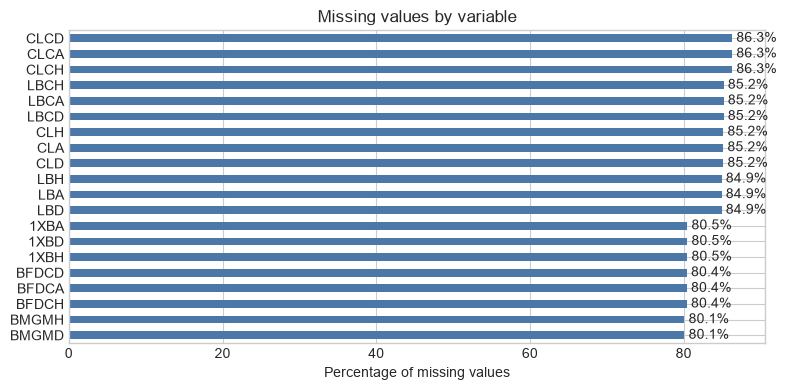

In [9]:
missing_pct = premier_df.isna().mean().mul(100).sort_values().tail(20)

fig, ax = plt.subplots(figsize=(8, 4))
missing_pct.plot(kind="barh", ax=ax, color="#4C78A8")
ax.set(title="Missing values by variable", xlabel="Percentage of missing values", ylabel="")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()


# 2. La variable objetivo (el resultado)

Además de ver cómo se reparten los resultados, calculamos un **punto de partida**: un modelo que siempre predice la clase más frecuente (victoria local, `H`) acertaría un 44.2% de las veces. Cualquier modelo tiene que superar ese número. Y como hay tres resultados y no están repartidos por igual, conviene mirar el acierto por separado para cada resultado (local, empate, visitante) en vez de solo el porcentaje total de aciertos.


In [10]:
target_summary = (
    premier_df["FTR"]
    .value_counts()
    .rename(index={"H": "Home Win", "D": "Draw", "A": "Away Win"})
    .to_frame("n")
)
target_summary["pct"] = target_summary["n"].div(len(premier_df)).mul(100)
target_summary


,n,pct
FTR,,
H,839,44.158
A,607,31.947
D,454,23.895


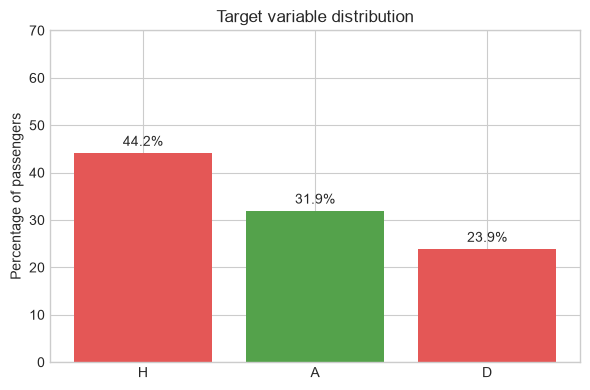

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(target_summary.index, target_summary["pct"], color=["#2CA02C", "#7F7F7F", "#D62728"])
ax.set(title="Full-time result distribution", ylabel="Percentage of matches", ylim=(0, 70))
ax.bar_label(bars, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()


### Interpretación

- **Observación:** De cada 100 partidos, unos 44 los gana el equipo de casa, unos 32 los gana el visitante y unos 24 acaban en empate.
- **Interpretación:** Se ve claramente que jugar en casa ayuda: el equipo local gana bastante más seguido que el visitante (como 12 de cada 100 partidos más). El empate es lo más raro de todo.
- **Decisión/Hipótesis:** Si tuviéramos que apostar a ciegas, lo más sensato sería decir siempre "gana el de casa", y acertaríamos unas 44 de cada 100 veces. Cualquier modelo tiene que hacerlo mejor que eso. Y como ganar en casa es tan frecuente, conviene mirar cuánto acierta el modelo en cada tipo de resultado (local, empate, visitante), no solo cuántos aciertos tiene en total.


# 3. Categorical variables and match outcome

To avoid misleading interpretations, the following tables report the group size (`n`) and the breakdown of outcomes (`H`, `D`, `A`) together.


In [12]:

def match_outcomes_summary(data, group_cols, target_col):
    """
    Resume la cantidad de partidos y el desglose de resultados (H, D, A) 
    para cualquier agrupación de variables.
    """
    if isinstance(group_cols, str):
        group_cols = [group_cols]
    
    # 1. Agrupamos y contamos las frecuencias de cada clase (H, D, A)
    summary = (
        data.groupby(group_cols, observed=True)[target_col]
        .value_counts()
        .unstack(fill_value=0) # Convierte las filas de clases en columnas
    )
    
    # 2. Calculamos el total de partidos para ese grupo
    summary["Total"] = summary.sum(axis=1)
    
    # 3. Calculamos los porcentajes dinámicamente para cada clase existente
    # Usamos las clases reales encontradas en la tabla pivote
    classes = [col for col in summary.columns if col != "Total"]
    
    for col in classes:
        summary[f"{col}_pct"] = (summary[col] / summary["Total"] * 100).round(2)
        
    return summary

# --- APLICACIÓN ---

# Desglose del resultado final (FTR) por Temporada
season_ftr_summary = match_outcomes_summary(premier_df, "Season", "FTR")

# Desglose del resultado al medio tiempo (HTR) por Temporada
season_htr_summary = match_outcomes_summary(premier_df, "HTR", "FTR")

referee_summary = match_outcomes_summary(premier_df, "Referee", "FTR")

nombre_casa = match_outcomes_summary(premier_df, "HomeTeam", "FTR")
nombre_visitante = match_outcomes_summary(premier_df, "AwayTeam", "FTR")
division_completo = match_outcomes_summary(premier_df, "Div", "FTR")


display(season_ftr_summary)
display(season_htr_summary)
display(referee_summary)
display(nombre_casa)
display(nombre_visitante)
display(division_completo)

FTR,A,D,H,Total,A_pct,D_pct,H_pct
Season,,,,,,,
2021-2022,129,88,163,380,33.950,23.160,42.890
2022-2023,109,87,184,380,28.680,22.890,48.420
2023-2024,123,82,175,380,32.370,21.580,46.050
2024-2025,132,93,155,380,34.740,24.470,40.790
2025-2026,114,104,162,380,30.000,27.370,42.630


FTR,A,D,H,Total,A_pct,D_pct,H_pct
HTR,,,,,,,
A,343,87,60,490,70.000,17.760,12.240
D,210,253,266,729,28.810,34.710,36.490
H,54,114,513,681,7.930,16.740,75.330


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Referee,,,,,,,
A Kitchen,0,3,3,6,0.000,50.000,50.000
A Madley,35,23,46,104,33.650,22.120,44.230
A Marriner,16,6,10,32,50.000,18.750,31.250
A Taylor,54,39,53,146,36.990,26.710,36.300
C Kavanagh,36,28,41,105,34.290,26.670,39.050
C Pawson,40,25,44,109,36.700,22.940,40.370
D Bond,5,6,12,23,21.740,26.090,52.170
D Coote,21,16,26,63,33.330,25.400,41.270
D England,25,23,39,87,28.740,26.440,44.830


FTR,A,D,H,Total,A_pct,D_pct,H_pct
HomeTeam,,,,,,,
Arsenal,12,15,68,95,12.630,15.790,71.580
Aston Villa,22,20,53,95,23.160,21.050,55.790
Bournemouth,24,24,28,76,31.580,31.580,36.840
Brentford,27,29,39,95,28.420,30.530,41.050
Brighton,24,31,40,95,25.260,32.630,42.110
Burnley,31,17,9,57,54.390,29.820,15.790
Chelsea,22,28,45,95,23.160,29.470,47.370
Crystal Palace,28,35,32,95,29.470,36.840,33.680
Everton,38,23,34,95,40.000,24.210,35.790


FTR,A,D,H,Total,A_pct,D_pct,H_pct
AwayTeam,,,,,,,
Arsenal,54,20,21,95,56.840,21.050,22.110
Aston Villa,36,18,41,95,37.890,18.950,43.160
Bournemouth,24,20,32,76,31.580,26.320,42.110
Brentford,29,20,46,95,30.530,21.050,48.420
Brighton,32,28,35,95,33.680,29.470,36.840
Burnley,7,16,34,57,12.280,28.070,59.650
Chelsea,39,22,34,95,41.050,23.160,35.790
Crystal Palace,27,28,40,95,28.420,29.470,42.110
Everton,22,29,44,95,23.160,30.530,46.320


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Div,,,,,,,
E0,607,454,839,1900,31.950,23.890,44.160


In [13]:
columnas_pct = ["H_pct", "D_pct", "A_pct"]
colores = ["#2CA02C", "#7F7F7F", "#D62728"] # Verde (H), Gris (D), Rojo (A)
leyenda_nombres = ["Home Win (H)", "Draw (D)", "Away Win (A)"]

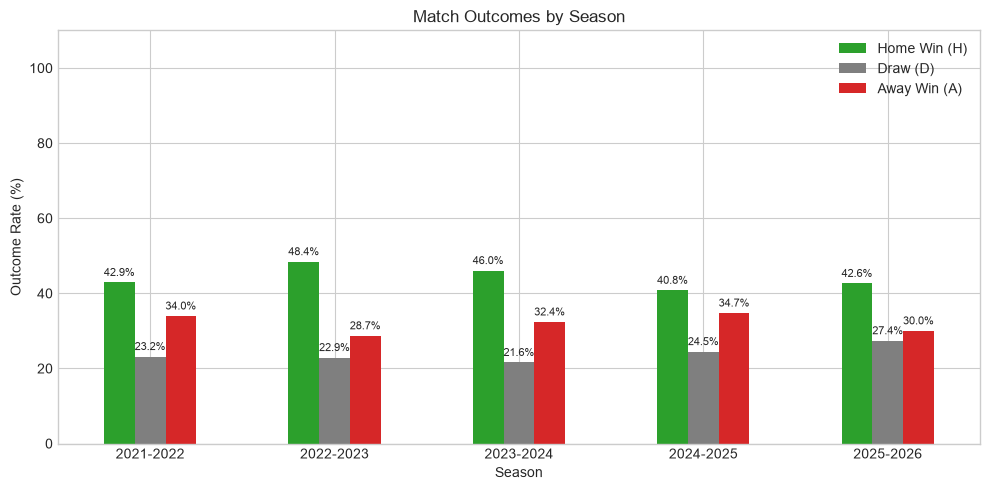

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

season_ftr_summary[columnas_pct].plot(kind="bar", ax=ax, color=colores, rot=0)
ax.set(title="Match Outcomes by Season", xlabel="Season", ylabel="Outcome Rate (%)", ylim=(0, 110))
ax.legend(leyenda_nombres)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, size=8)

plt.tight_layout()
plt.show()

### Interpretación

- **Observación:** En las 5 temporadas, ganar en casa va de 41 a 48 de cada 100 partidos, el empate de 22 a 27, y ganar fuera de 29 a 35. Cada temporada tiene 380 partidos.
- **Interpretación:** En todas las temporadas el local gana más que el visitante, o sea que la ventaja de casa se mantiene año tras año. Las pequeñas diferencias entre temporadas (unos 4 puntos arriba o abajo) son demasiado chicas como para hablar de una tendencia real: con 380 partidos, un porcentaje puede moverse varios puntos por pura suerte.
- **Decisión/Hipótesis:** La temporada por sí sola no dice mucho. Sirve más para ordenar los datos de forma lógica (por ejemplo, entrenar con los años viejos y comprobar con los nuevos) que para usarla como una pista fuerte para predecir.


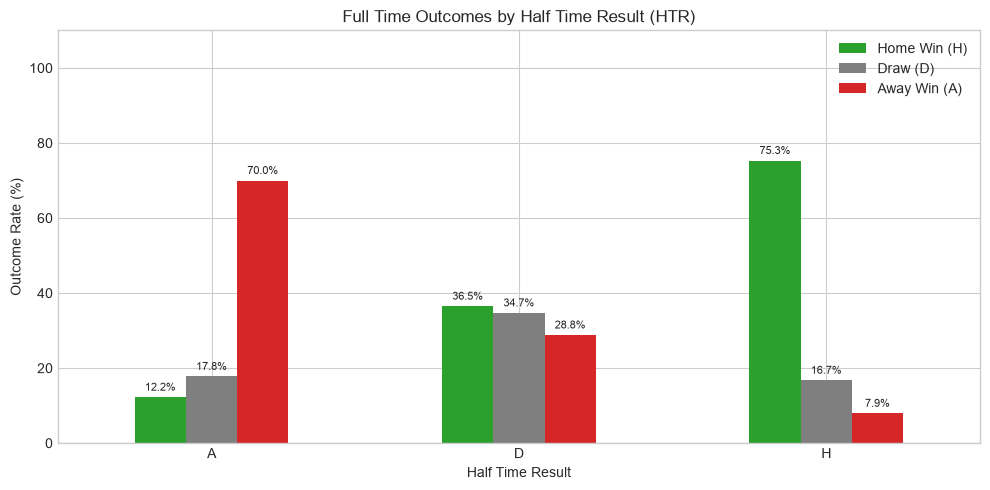

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

season_htr_summary[columnas_pct].plot(kind="bar", ax=ax, color=colores, rot=0)
ax.set(title="Full Time Outcomes by Half Time Result (HTR)", xlabel="Half Time Result", ylabel="Outcome Rate (%)", ylim=(0, 110))
ax.legend(leyenda_nombres)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, size=8)

plt.tight_layout()
plt.show()

### Interpretación

- **Observación:** Si un equipo va ganando al descanso, gana el partido completo unas 3 de cada 4 veces. Si va perdiendo, acaba perdiendo 7 de cada 10 veces. Y si va empatado, al final puede pasar cualquier cosa (los tres resultados casi a tercios).
- **Interpretación:** Lo que pasa en el primer tiempo se repite muchísimo en el resultado final. Solo 1 de cada 4 partidos le da la vuelta a un marcador que iba a favor de un equipo en el descanso.
- **Decisión/Hipótesis:** Ese dato sería oro para predecir, pero no se puede usar: antes del partido nadie sabe el marcador del descanso. Meterlo en el modelo sería hacer trampa, porque el modelo usaría información que todavía no existe y parecería buenísimo sin serlo. Solo serviría para apostar con el partido ya empezado, no para un pronóstico previo.


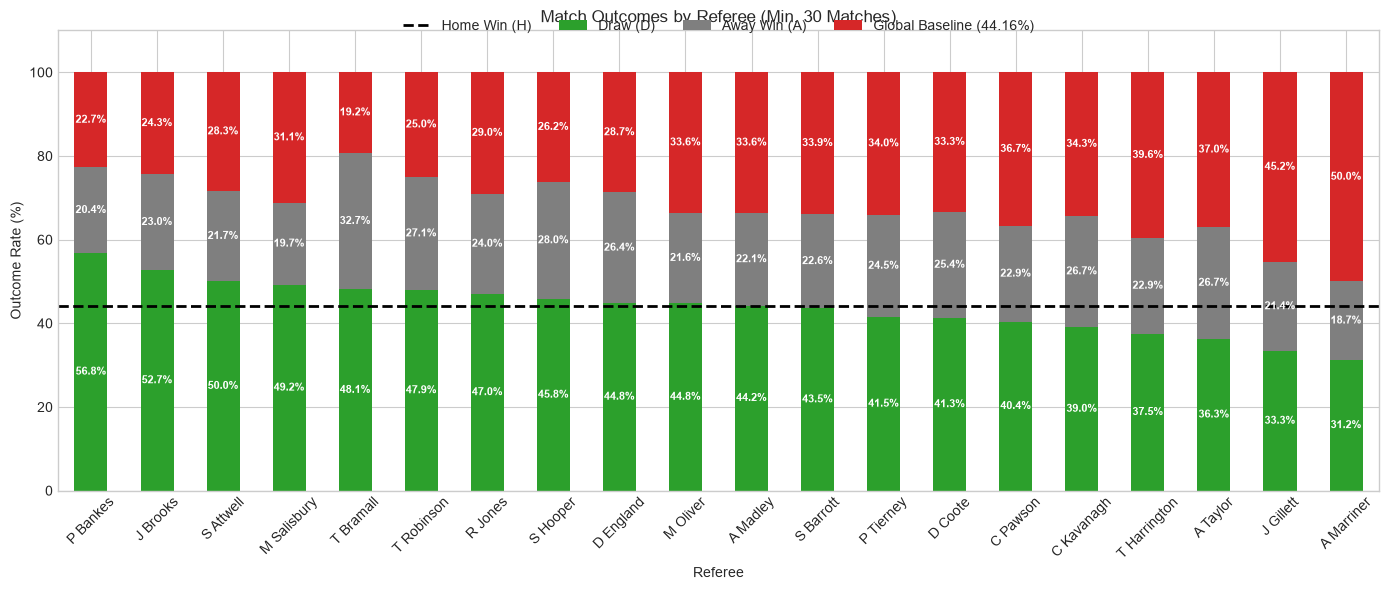

--- Referees with HIGHEST Home Win Rate ---


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Referee,,,,,,,
P Bankes,20,18,50,88,22.730,20.450,56.820
J Brooks,18,17,39,74,24.320,22.970,52.700
S Attwell,30,23,53,106,28.300,21.700,50.000


\n--- Referees with LOWEST Home Win Rate ---


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Referee,,,,,,,
A Taylor,54,39,53,146,36.990,26.710,36.300
J Gillett,38,18,28,84,45.240,21.430,33.330
A Marriner,16,6,10,32,50.000,18.750,31.250


In [16]:
# árbitros con al menos 30 partidos (para significancia estadística)
referees_filtered = referee_summary[referee_summary['Total'] >= 30].copy()

referees_filtered = referees_filtered.sort_values(by="H_pct", ascending=False)

referees_plot_data = referees_filtered[["H_pct", "D_pct", "A_pct"]]

fig, ax = plt.subplots(figsize=(14, 6))

referees_plot_data.plot(kind="bar", stacked=True, ax=ax, color=colores, rot=45)

plt.axhline(y=44.16, color='black', linestyle='--', linewidth=2, label='Global Home Win Baseline (44.16%)')

ax.set(title="Match Outcomes by Referee (Min. 30 Matches)",  xlabel="Referee", ylabel="Outcome Rate (%)", ylim=(0, 110))

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["Home Win (H)", "Draw (D)", "Away Win (A)", "Global Baseline (44.16%)"], 
          loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type='center', size=8, color='white', weight='bold')

plt.tight_layout()
plt.show()

#valores extremos
print("--- Referees with HIGHEST Home Win Rate ---")
display(referees_filtered.head(3))
print("\\n--- Referees with LOWEST Home Win Rate ---")
display(referees_filtered.tail(3))

### Conclusión: el árbitro influye poco (y mejor no usarlo)

- **Observación:** Los resultados no son iguales con todos los árbitros: algunos terminan con más victorias de local que otros, incluso mirando solo a los que dirigieron 30 partidos o más.
- **Interpretación:** Esa diferencia no significa que el árbitro decida el resultado. Los árbitros no se reparten al azar (a unos les tocan equipos más fuertes que a otros), y con 40 árbitros, algunos van a parecer "especiales" solo por casualidad. Además, cada árbitro dirige pocos partidos, así que su porcentaje puede cambiar mucho por pura suerte.
- **Decisión/Hipótesis:** Meter al árbitro en el modelo es arriesgado: el modelo podría memorizar coincidencias en vez de aprender algo real. Mejor dejarlo fuera y quedarnos con lo que sí importa (la fuerza de los equipos y las cuotas).


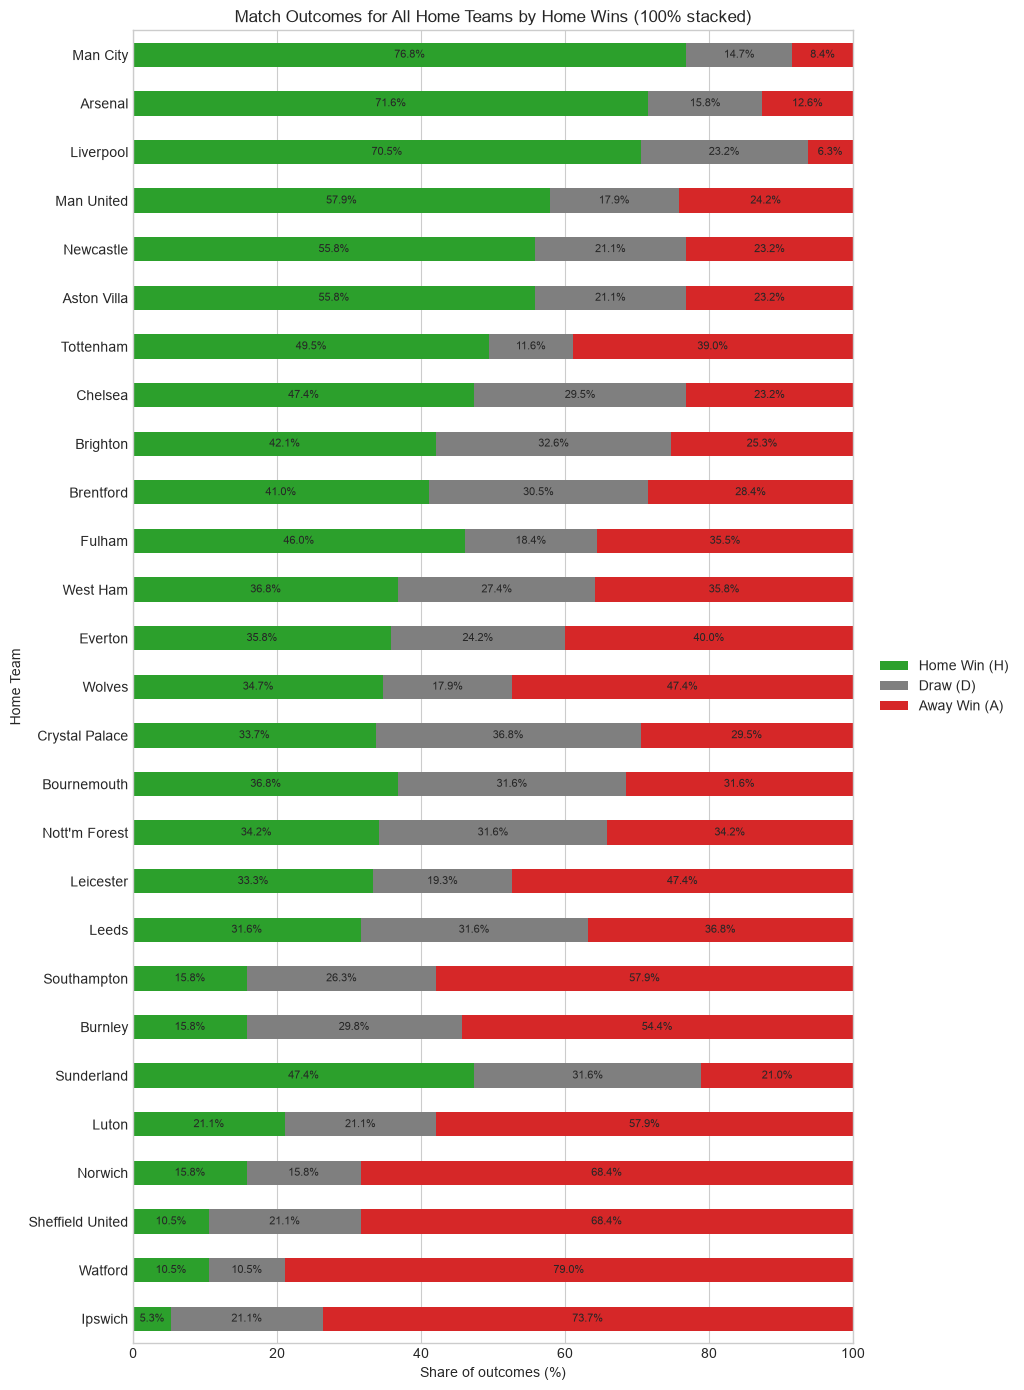

In [31]:
fig, ax = plt.subplots(figsize=(11, 14))

# Todos los equipos ordenados por victorias de local (H): el que más ganó arriba
top_home_teams = nombre_casa.sort_values("H", ascending=False).iloc[::-1]

# Una sola barra horizontal por equipo: en verde gana (H), en rojo pierde (A)
top_home_teams[columnas_pct].plot(kind="barh", stacked=True, ax=ax, color=colores)
ax.set(title="Match Outcomes for All Home Teams by Home Wins (100% stacked)", xlabel="Share of outcomes (%)", ylabel="Home Team", xlim=(0, 100))
ax.legend(leyenda_nombres, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", size=8)

plt.tight_layout()
fig.subplots_adjust(right=0.78)
plt.show()

### Interpretación

- **Observación:** Los equipos están muy ordenados: los de arriba ganan en casa entre 60 y 70 de cada 100 partidos, y los de abajo entre 20 y 30. El promedio general es 44.
- **Interpretación:** Quién es el equipo de casa importa muchísimo: el orden se parece a la fuerza real de cada equipo, con los grandes arriba y los chicos abajo. Dice bastante más que la temporada o el árbitro.
- **Decisión/Hipótesis:** El equipo es información de verdad y hay que aprovecharla. Pero meter 27 equipos como si fueran 27 cajitas sueltas es muchísimo; mejor resumirlos en un solo número que diga lo bueno que es cada uno (por ejemplo, sus puntos por partido), o dejárselo a las cuotas de apuestas, que ya lo resumen por nosotros.


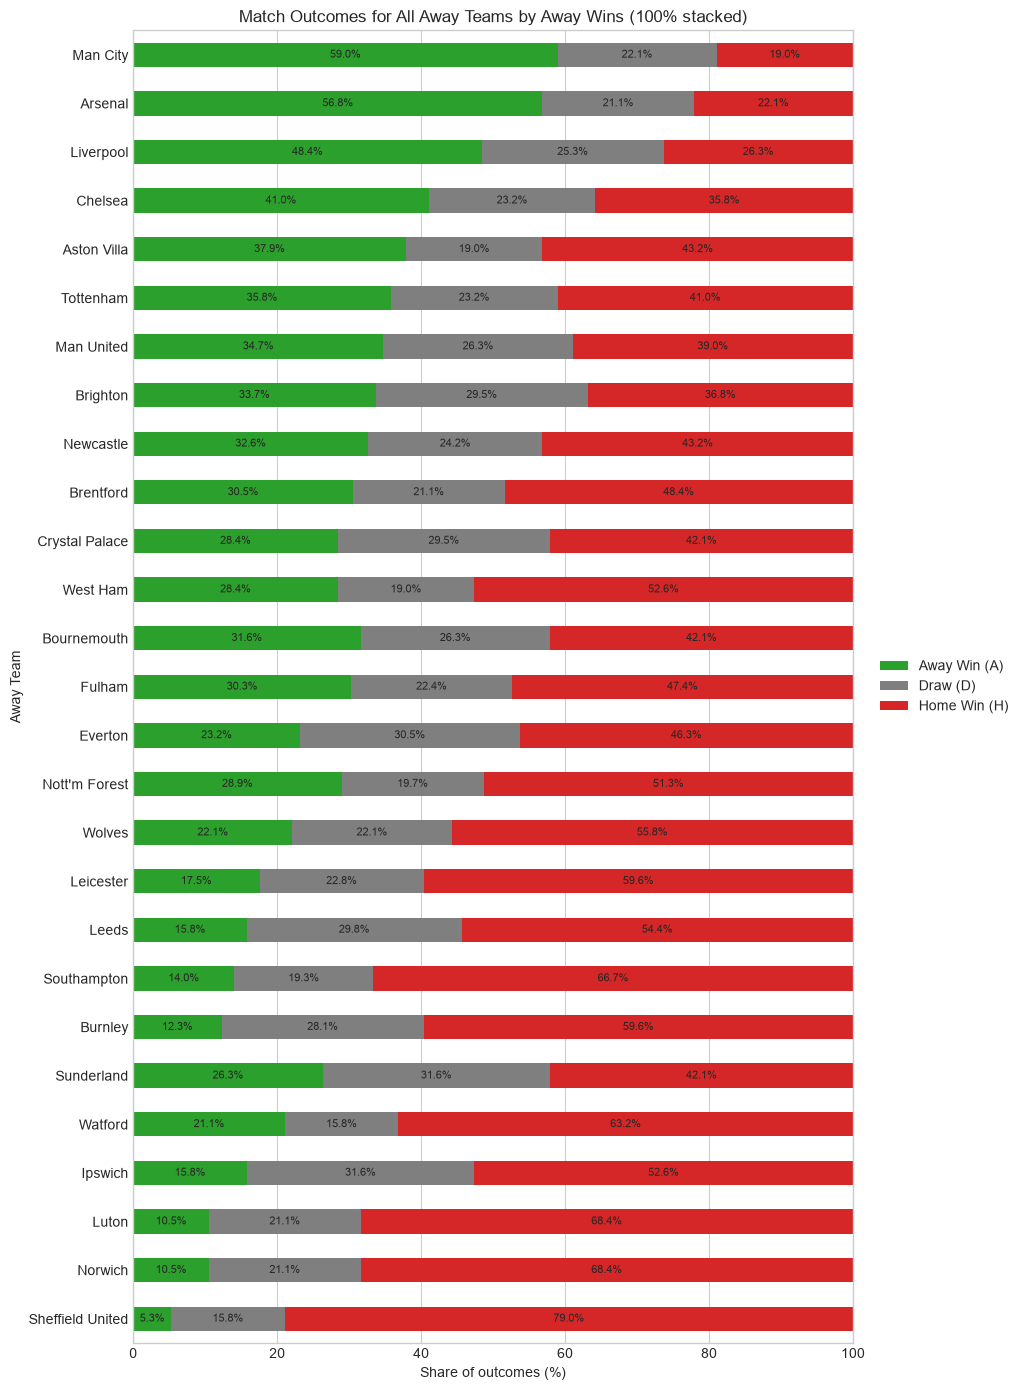

In [32]:
fig, ax = plt.subplots(figsize=(11, 14))

# Todos los equipos ordenados por victorias de visitante (A): el que más ganó arriba
top_away_teams = nombre_visitante.sort_values("A", ascending=False).iloc[::-1]

# Orden lógico para el equipo evaluado (visitante): ganó (A), empató (D), perdió (H)
top_away_teams[["A_pct", "D_pct", "H_pct"]].plot(kind="barh", stacked=True, ax=ax, color=colores)
ax.set(title="Match Outcomes for All Away Teams by Away Wins (100% stacked)", xlabel="Share of outcomes (%)", ylabel="Away Team", xlim=(0, 100))
ax.legend(["Away Win (A)", "Draw (D)", "Home Win (H)"], loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", size=8)

plt.tight_layout()
fig.subplots_adjust(right=0.78)
plt.show()

### Interpretación

- **Observación:** Como visitante también hay orden entre equipos, pero más apretado: el mejor gana fuera como mucho la mitad de los partidos, y el peor más o menos 15 de cada 100. El centro está en 32.
- **Interpretación:** Jugar fuera hace que las diferencias entre equipos se achiquen: cuesta más ganar de visitante, así que hasta los buenos bajan y todos quedan más juntos. El orden de quién es mejor se mantiene, pero comprimido.
- **Decisión/Hipótesis:** Conviene tratar "lo bueno que es un equipo en casa" y "lo bueno que es fuera" como dos cosas distintas, porque no rinden igual en los dos sitios.


In [19]:
home_team_season_summary = match_outcomes_summary( premier_df, [ "HomeTeam", "Season" ], "FTR")
#display(home_team_season_summary)
away_team_season_summary = match_outcomes_summary( premier_df, [ "AwayTeam", "Season" ], "FTR")
#display(away_team_season_summary)


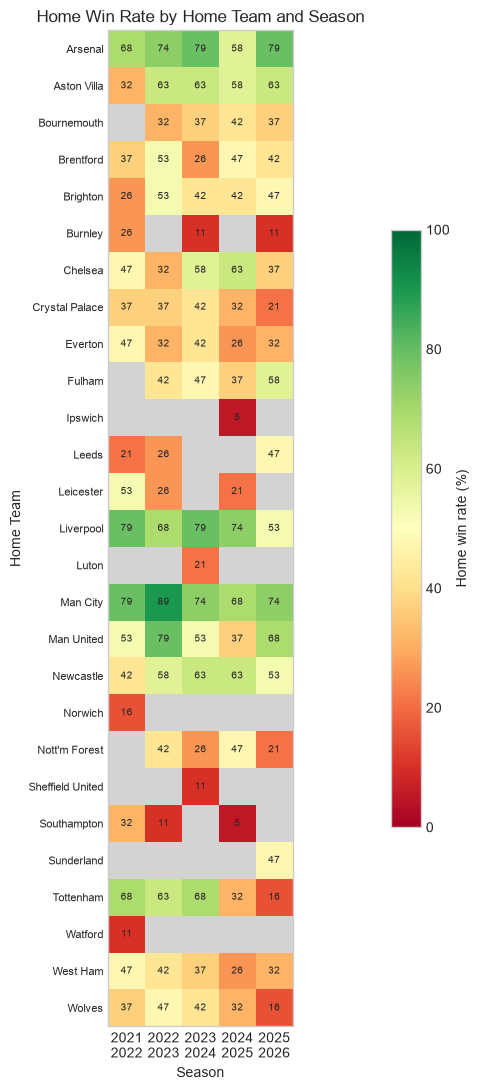

In [20]:
# Chart 1: home win rate by home team and season
home_season_pivot = home_team_season_summary["H_pct"].unstack("Season")

cmap = plt.cm.RdYlGn.copy()
cmap.set_bad("lightgray")

fig, ax = plt.subplots(figsize=(20, 11))
im = ax.imshow(home_season_pivot.values, cmap=cmap, vmin=0, vmax=100)
ax.set_xticks(range(home_season_pivot.shape[1]))
ax.set_xticklabels([c.replace("-", "\n") for c in home_season_pivot.columns], fontsize=10)
ax.set_yticks(range(home_season_pivot.shape[0]))
ax.set_yticklabels(home_season_pivot.index, fontsize=8)
ax.grid(False)
ax.set_title("Home Win Rate by Home Team and Season")
ax.set_xlabel("Season")
ax.set_ylabel("Home Team")

for i in range(home_season_pivot.shape[0]):
    for j in range(home_season_pivot.shape[1]):
        val = home_season_pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Home win rate (%)", shrink=0.6)
plt.tight_layout()
plt.show()


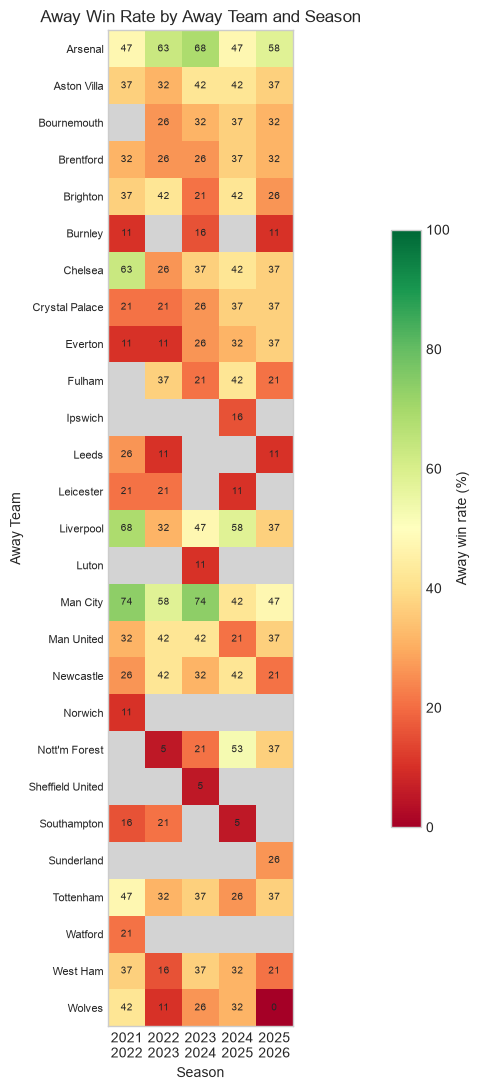

In [21]:
# Chart 2: away win rate by away team and season
away_season_pivot = away_team_season_summary["A_pct"].unstack("Season")

cmap = plt.cm.RdYlGn.copy()
cmap.set_bad("lightgray")

fig, ax = plt.subplots(figsize=(20, 11))
im = ax.imshow(away_season_pivot.values, cmap=cmap, vmin=0, vmax=100)
ax.set_xticks(range(away_season_pivot.shape[1]))
ax.set_xticklabels([c.replace("-", "\n") for c in away_season_pivot.columns], fontsize=10)
ax.set_yticks(range(away_season_pivot.shape[0]))
ax.set_yticklabels(away_season_pivot.index, fontsize=8)
ax.grid(False)
ax.set_title("Away Win Rate by Away Team and Season")
ax.set_xlabel("Season")
ax.set_ylabel("Away Team")

for i in range(away_season_pivot.shape[0]):
    for j in range(away_season_pivot.shape[1]):
        val = away_season_pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Away win rate (%)", shrink=0.6)
plt.tight_layout()
plt.show()


### Interpretación (mapas de calor: equipo por temporada)

- **Observación:** En el mapa, lo primero que salta a la vista son los huecos: algunos equipos aparecen en todas las temporadas y otros solo en una o dos. Cada equipo juega 19 partidos por temporada.
- **Interpretación:** Los huecos son importantísimos y no son un detalle: los equipos que faltan son los que descendieron a una liga menor (o ascendieron y por eso no están en todas). Y hay una relación muy clara: los equipos que faltan en más temporadas suelen rendir peor. Si ordenamos los equipos por cuántas temporadas llevan en la liga, los que estuvieron las 5 temporadas ganan de media el 44% de sus partidos, mientras que los que solo estuvieron 1 temporada ganan el 17%. Dicho de otra forma: quedarse en la máxima categoría ya dice mucho de lo bueno que es un equipo.
- **Decisión/Hipótesis:** Lo que sí sirve del mapa no es el color de cada casilla (son pocos partidos y se ve mucho ruido), sino el patrón de presencia: cuántas temporadas lleva el equipo en la liga (o si viene de ascender) es una pista simple, potente y conocida antes de cada partido. Esa sí la probaría como característica del modelo.


### Advertencia: porcentajes con pocos partidos

Algunos de estos porcentajes salen de muy pocos partidos, y hay que tomarlos con cuidado por tres motivos.

- **Pocos partidos, mucho azar:** un equipo solo juega 19 partidos por temporada, así que su porcentaje puede cambiar muchísimo por pura suerte. Dos equipos que parecen estar separados por 15 puntos de diferencia pueden ser en realidad igual de buenos, y lo que vemos es solo ruido. Con los árbitros es peor: hay árbitros con 1 partido y otros con 146 (la mayoría ronda los 29), y con menos de 10 partidos su porcentaje es prácticamente una moneda al aire.
- **Mirar los extremos engaña:** si ordenamos unos 27 equipos o unos 40 árbitros y nos fijamos en los de arriba y los de abajo, siempre va a parecer que alguno es "especial", pero parte de eso es pura casualidad.
- **Los árbitros no se reparten al azar:** un árbitro con muchas victorias locales puede haberlas conseguido porque le tocaron rivales débiles, no porque él influya. Además, un equipo con una temporada buenísima (o malísima) tiende a volver hacia el promedio en la siguiente.

*Decisión:* mostrar siempre cuántos partidos hay detrás de cada porcentaje, y solo fiarse de diferencias más grandes que el margen de error que da el azar. En el modelo, tratar al equipo y al árbitro con cuidado (resumirlos o dejarlos fuera) en vez de tratarlos como cajitas sueltas, y usar las cuotas de apuestas como medida de la fuerza de cada equipo, sin meter información que no exista antes del partido.


# 4. Home/Away: la categórica más fuerte

Cada fila ya codifica la localía desde la perspectiva del equipo local: `FTR = H` es victoria local, `A` victoria visitante, `D` empate. Por eso la distribución del target **es** el análisis de Home/Away: el *home advantage* es la diferencia entre `P(H)` y `P(A)`.

Para demostrar que la ventaja local no es un artefacto de 2-3 equipos, comparamos la tasa de victoria **en casa vs fuera** de cada equipo.


In [ ]:
# Construimos una tabla larga: cada fila = un equipo en un partido, con su localía
home_part = premier_df[["HomeTeam", "FTR"]].copy()
home_part["venue"] = "Home"
home_part["win"] = home_part["FTR"].eq("H").astype(int)
home_part["draw"] = home_part["FTR"].eq("D").astype(int)
home_part = home_part.rename(columns={"HomeTeam": "team"})

away_part = premier_df[["AwayTeam", "FTR"]].copy()
away_part["venue"] = "Away"
away_part["win"] = away_part["FTR"].eq("A").astype(int)
away_part["draw"] = away_part["FTR"].eq("D").astype(int)
away_part = away_part.rename(columns={"AwayTeam": "team"})

venue_long = pd.concat([home_part, away_part], ignore_index=True)

# Tasa de victoria y puntos por partido (PPG) por localía
home_advantage = venue_long.groupby("venue").agg(
    n=("win", "size"),
    win_pct=("win", lambda s: s.mean() * 100),
    draw_pct=("draw", lambda s: s.mean() * 100),
).round(1)
home_advantage["ppg"] = (3 * home_advantage["win_pct"] / 100 + home_advantage["draw_pct"] / 100).round(2)
home_advantage

# El home advantage como delta de win% y de PPG
delta_win = home_advantage.loc["Home", "win_pct"] - home_advantage.loc["Away", "win_pct"]
delta_ppg = home_advantage.loc["Home", "ppg"] - home_advantage.loc["Away", "ppg"]
print(f"Home advantage (win%): {delta_win:.1f} pp")
print(f"Home advantage (PPG):  {delta_ppg:.2f} ppg")


In [ ]:
team_n = venue_long.groupby("team")["win"].size()

team_venue = venue_long.groupby(["team", "venue"])["win"].mean().mul(100).round(1).unstack("venue")
team_venue["n"] = team_n

home_global = home_advantage.loc["Home", "win_pct"]
away_global = home_advantage.loc["Away", "win_pct"]

fig, ax = plt.subplots(figsize=(8, 8))
color = ["#2CA02C" if h >= a else "#D62728" for h, a in zip(team_venue["Home"], team_venue["Away"])]
ax.scatter(team_venue["Home"], team_venue["Away"], s=team_venue["n"] * 2, c=color, alpha=0.7)

# Referencias: diagonal (neutral a nivel equipo) y centro poblacional
ax.plot([0, 100], [0, 100], "--", color="gray", label="Sin ventaja local (Home = Away)")
ax.axvline(home_global, color="#2CA02C", linestyle=":", alpha=0.6, label=f"Win% casa global ({home_global:.1f}%)")
ax.axhline(away_global, color="#D62728", linestyle=":", alpha=0.6, label=f"Win% fuera global ({away_global:.1f}%)")

ax.set(
    title="Win rate: home vs away, por equipo",
    xlabel="Win % en casa",
    ylabel="Win % fuera",
    xlim=(0, 100),
    ylim=(0, 100),
)
for team in team_venue.index:
    ax.annotate(team, (team_venue.loc[team, "Home"], team_venue.loc[team, "Away"]), fontsize=7)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Interpretación

- **Observación:** En la gráfica de la línea recta, cada punto es un equipo: en horizontal se ve cuánto gana en casa y en vertical cuánto gana fuera. La línea recta que cruza es la frontera donde ganar en casa es igual que ganar fuera: si un punto cayera justo encima de esa línea, a ese equipo le daría exactamente igual jugar de local o de visitante.
- **Interpretación:** Casi todos los puntos están por encima de esa línea. Estar por encima significa que el equipo gana más en casa que fuera. Como les pasa a casi todos, la ventaja de jugar en casa es algo general de toda la liga, no una rareza de uno o dos equipos.
- **Decisión/Hipótesis:** Esa ventaja de casa se puede meter en el modelo como un empujón fijo que se le da al equipo local, o separando lo bueno que es cada equipo en casa y lo bueno que es fuera. Los nombres de equipo se resumen en un número de fuerza, no como 27 cajitas sueltas.
